In [1]:
import tensorflow as tf

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Your CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])


C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'LAB/image1',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    'LAB/image1',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 144 images belonging to 2 classes.
Found 36 images belonging to 2 classes.


In [4]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_generator, validation_data=val_generator, epochs=5)


C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 760ms/step - accuracy: 0.5472 - loss: 1.2502 - val_accuracy: 0.4167 - val_loss: 0.7129
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step - accuracy: 0.5548 - loss: 0.6833 - val_accuracy: 0.5833 - val_loss: 0.7207
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - accuracy: 0.6224 - loss: 0.6681 - val_accuracy: 0.5833 - val_loss: 0.6881
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - accuracy: 0.6267 - loss: 0.6866 - val_accuracy: 0.5833 - val_loss: 0.6868
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - accuracy: 0.4613 - loss: 0.6975 - val_accuracy: 0.5833 - val_loss: 0.6825


In [5]:
# Get one image
sample_image, label = next(val_generator)
img = sample_image[0]  # Shape: (150, 150, 3)
img_batch = np.expand_dims(img, axis=0)


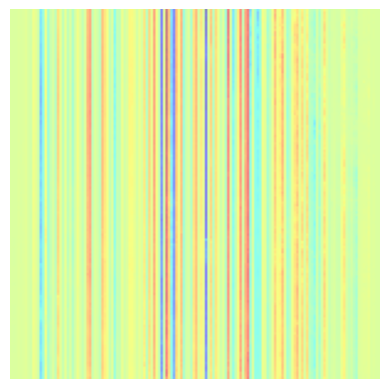

In [7]:
with tf.GradientTape() as tape:
    img_tensor = tf.convert_to_tensor(img_batch)
    tape.watch(img_tensor)
    loss = model(img_tensor)[0]

grads = tape.gradient(loss, img_tensor)[0].numpy()
lrp_map = np.sum(grads[0] * img,axis=-1)

plt.imshow(lrp_map, cmap='jet', alpha=0.5)
plt.axis('off')
plt.show()
